<a href="https://colab.research.google.com/github/nabillahumi/S5-Mesin_Learning/blob/main/Jobsheet6%20Regresi/Tugas_Praktikum_(JS6R).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Langkah 1: Import Library & Load Dataset

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
dataset = pd.read_csv('insurance.csv')

# Menampilkan 5 data teratas
print(dataset.head())

   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520


#Langkah 2: Encoding Variabel Kategorikal & Identifikasi Fitur

In [3]:
# Transformasi variabel kategorikal menjadi numerik
dataset_encoded = pd.get_dummies(dataset, columns=['sex', 'smoker', 'region'], drop_first=True)

# Memisahkan Fitur (X) dan Target (y)
X = dataset_encoded.drop('charges', axis=1)
y = dataset_encoded['charges']

print("Daftar Fitur X setelah Encoding:")
print(X.columns.tolist())

Daftar Fitur X setelah Encoding:
['age', 'bmi', 'children', 'sex_male', 'smoker_yes', 'region_northwest', 'region_southeast', 'region_southwest']


#Langkah 3: Pembagian Data Latih dan Data Uji (Train/Test Split)

In [4]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Jumlah Data Latih : {X_train.shape[0]}")
print(f"Jumlah Data Uji   : {X_test.shape[0]}")

Jumlah Data Latih : 1070
Jumlah Data Uji   : 268


#Langkah 4: Feature Scaling (Penskalaan Fitur)

In [5]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#Langkah 5: Membuat & Melatih Model Multiple Linear Regression

In [6]:
from sklearn.linear_model import LinearRegression

# Inisialisasi dan fitting model
model = LinearRegression()
model.fit(X_train_scaled, y_train)

# Menampilkan koefisien regresi
print("Intercept (b0):", model.intercept_)
for col, coef in zip(X.columns, model.coef_):
    print(f"Koefisien {col}: {coef:.2f}")

Intercept (b0): 13346.089736364485
Koefisien age: 3614.98
Koefisien bmi: 2036.23
Koefisien children: 516.89
Koefisien sex_male: -9.29
Koefisien smoker_yes: 9558.48
Koefisien region_northwest: -158.14
Koefisien region_southeast: -290.16
Koefisien region_southwest: -349.11


#Langkah 6: Prediksi pada Data Uji & Visualisasi Hasil

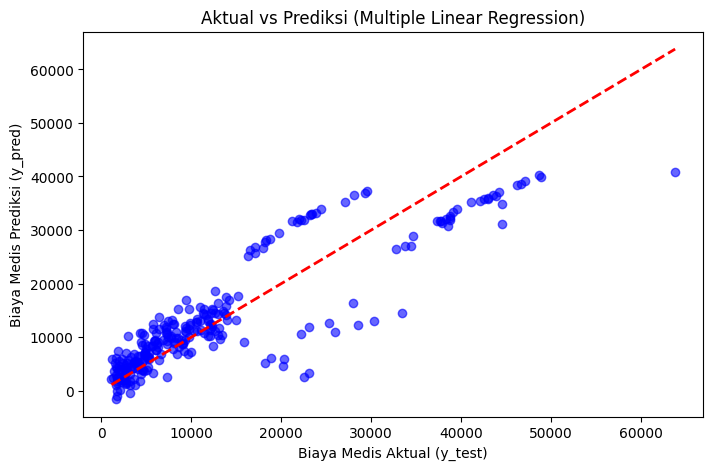

In [7]:
# Melakukan prediksi pada data uji
y_pred = model.predict(X_test_scaled)

# Visualisasi Data Aktual vs Hasil Prediksi
plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred, alpha=0.6, color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Biaya Medis Aktual (y_test)')
plt.ylabel('Biaya Medis Prediksi (y_pred)')
plt.title('Aktual vs Prediksi (Multiple Linear Regression)')
plt.show()

#Langkah 7: Evaluasi Model

In [8]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("=== Hasil Evaluasi Model ===")
print(f"MAE       : {mae:.2f}")
print(f"MSE       : {mse:.2f}")
print(f"RMSE      : {rmse:.2f}")
print(f"R-squared : {r2:.4f}")

=== Hasil Evaluasi Model ===
MAE       : 4181.19
MSE       : 33596915.85
RMSE      : 5796.28
R-squared : 0.7836


#Langkah 8: Analisis Hasil

**Analisis Hasil Evaluasi Model**

- Koefisien Determinasi (R²): Model mampu menjelaskan 78,36% perubahan biaya medis (charges). Artinya, fitur yang digunakan cukup baik untuk memperkirakan biaya medis.

- MAE: Rata-rata selisih antara biaya prediksi dan biaya sebenarnya adalah $4.181,19.

- RMSE: Nilai RMSE yang lebih besar daripada MAE menunjukkan adanya beberapa prediksi yang memiliki selisih cukup besar dari biaya sebenarnya.

**Analisis Grafik Aktual vs Prediksi**

- Biaya di bawah $15.000: Titik-titik data banyak berada dekat garis merah. Artinya, prediksi biaya pada rentang ini cukup mendekati nilai sebenarnya.

- Biaya di atas $20.000: Titik-titik data terlihat menyebar dan membentuk dua kelompok. Hal ini menunjukkan bahwa model regresi linier belum mampu mengikuti pola biaya tinggi dengan baik, terutama jika terdapat pengaruh gabungan dari faktor seperti kebiasaan merokok dan BMI yang tinggi.